# Error bars

pyGSTi gives you two independent routes to uncertainties on a GST estimate. The first is the Hessian-based confidence region: pyGSTi computes the Hessian of the loglikelihood at the estimate, projects out the gauge directions, and hands you a region you can propagate through any function of the model. This is what reports use, and it is fast. The second is bootstrapping: refit the model many times on resampled data and take the spread of the results. Bootstrapping costs one GST fit per resample and makes fewer assumptions about the shape of the likelihood near its maximum, but in practice we have found the two agree closely enough that the Hessian route is usually the better trade.

This page runs both on the same simulated dataset so you can compare them.

## Setup

Simulate a noisy 1-qubit GST experiment. Everything below reuses this one dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pygsti
from pygsti.modelpacks import smq1Q_XY
from pygsti.report import reportables as rptbl, modelfunction as modelfn

In [2]:
target_model = smq1Q_XY.target_model('full TP')

prep_fiducials = smq1Q_XY.prep_fiducials()
meas_fiducials = smq1Q_XY.meas_fiducials()
germs = smq1Q_XY.germs()
max_lengths = [1, 2, 4, 8, 16]

edesign = pygsti.protocols.StandardGSTDesign(
    smq1Q_XY.processor_spec(), prep_fiducials, meas_fiducials, germs, max_lengths)

mdl_datagen = target_model.depolarize(op_noise=0.1, spam_noise=0.001)
ds = pygsti.data.simulate_data(mdl_datagen, edesign, num_samples=1000,
                               sample_error='binomial', seed=1234)

Fit two parameterizations in one pass. The confidence-region section below uses the CPTPLND estimate. The bootstrap section uses the `full TP` estimate instead: the bootstrap helpers refit against whatever `target_model` you hand them and then pack the summarized results back into a copy of the estimate you pass in, so the estimate has to carry the same parameterization as `target_model`, which is `full TP` here.

In [3]:
gst_proto = pygsti.protocols.StandardGST(modes=['full TP', 'CPTPLND'], verbosity=1)
results = gst_proto.run(pygsti.protocols.ProtocolData(edesign, ds))

-- Std Practice:  [##################################################] 100.0%  (CPTPLND) --


## Hessian-based confidence regions

Attach a `ConfidenceRegionFactory` to the estimate, compute and project the Hessian, then take a 95% confidence-region "view".

In [4]:
crfact = results.estimates['CPTPLND'].add_confidence_region_factory('stdgaugeopt', 'final')
crfact.compute_hessian(comm=None, mem_limit=3.0*(1024.0)**3)  # optionally use multiple processors & set memlimit
crfact.project_hessian('intrinsic error')
crf_view = results.estimates['CPTPLND'].confidence_region_factories['stdgaugeopt', 'final'].view(95)

  Layout creation w/mem limit = 3.00GB
  Using MapForwardSimulator without MPI
    Param-processors already occupy a single node, dividing param-processor into 1 param2-processors.
*** Divided 1-host param-processor (~1 procs) into 1 param2-processing groups ***
     Estimated memory required = 0.0GB
rank 0: 5.24521e-06s: beginning atom 1/1, atom-size (#circuits) = 872


<repo>/pygsti/protocols/estimate.py:508: UserWarning: 
                The model labeled 'stdgaugeopt' has fewer parameters than the
                model labeled 'final iteration estimate'. By convention, the latter
                model is the final model from GST model fitting for which optimization
                was performed. This makes it  unlikely that the former model
                is actually optimal (e.g., in the sense of log-likelihood) among its
                entire hypothesis class. Suboptimality of 'stdgaugeopt' within its
                hypothesis class invalidates most statistical assumptions required to
                compute confidence regions.
                
                Caution should be used when interpeting confidence regions for
                model 'stdgaugeopt'.
                
  _warnings.warn(msg, UserWarning)


rank 0: 0.879509s: block 1/1, atom 1/1, atom-size (#circuits) = 872
  Layout creation w/mem limit = 3.00GB
  Using MapForwardSimulator without MPI
     Estimated memory required = 0.0GB
    
--- Hessian Projector Optimization from separate SPAM and Gate weighting ---
  Resulting intrinsic errors: 278525 (gates), 115687 (spam)
  Resulting sqrt(mean(operationCIs**2)): 61841.5
  Resulting sqrt(mean(spamCIs**2)): 57488.7


If you want a report on disk carrying these error bars, now is the moment to write it (see the [reports guide](Reports)). This page is about the numbers themselves, so we move on.

The `pygsti.report.reportables` module described in the [model-analysis metrics guide](Metrics) is the other half of this. Wrap any function of a model in a `ModelFunction` and pyGSTi will propagate the confidence region through it, giving you an error bar on whatever you asked for.

Start with the simplest case: error bars on a process matrix. The `ModelFunction` only has to return the operation, but it has to return a *copy* of it. `to_dense()` hands back a view of the model's internal storage, and the finite-difference machinery perturbs that same model in place; without the copy the base value moves along with the perturbed one, every derivative comes out exactly zero, and so does every error bar.

In [5]:
final_model = results.estimates['CPTPLND'].models['stdgaugeopt'].copy()

In [6]:
def get_op(model, lbl):
    return model[lbl].to_dense().copy()
get_op_modelfn = modelfn.modelfn_factory(get_op)

In [7]:
rptbl.evaluate(get_op_modelfn(final_model, ("Gxpi2", 0)), crf_view)

ReportableQty([[ 1.00000000e+00  5.97056811e-19  4.15945613e-17  2.40488363e-17]
 [ 9.24899317e-04  9.00024601e-01  1.04084959e-03 -3.47148671e-02]
 [-1.25297266e-02  3.43485151e-02  1.22152493e-02 -8.85435662e-01]
 [ 1.30453782e-02  1.41135687e-03  9.16990754e-01 -1.21525639e-02]] +/- [[0.00068284 0.00232363 0.00864314 0.00794758]
 [0.00216669 0.00704737 0.00941957 0.00915696]
 [0.00582702 0.00892778 0.01174099 0.00367212]
 [0.00522544 0.00812963 0.00353869 0.00631684]])

In [8]:
rptbl.evaluate(get_op_modelfn(final_model, ("Gypi2", 0)), crf_view)

ReportableQty([[ 1.00000000e+00 -4.22016873e-17 -5.37548297e-19  2.34600946e-17]
 [-6.42805474e-03 -4.48185618e-02  2.23944345e-02  8.85383996e-01]
 [-1.17066749e-03 -2.17661502e-02  9.01185675e-01  2.27488373e-02]
 [-2.93966183e-03 -9.17047046e-01  2.13850738e-02  3.45518958e-02]] +/- [[0.00068831 0.00881723 0.00224805 0.00825954]
 [0.00531789 0.01014903 0.01132452 0.00384792]
 [0.00209864 0.00820965 0.00733364 0.00836747]
 [0.00496051 0.00372356 0.00977037 0.00610721]])

Nothing restricts you to raw matrix elements. The wrapped function can compute any derived quantity, including the other reportables. Note the calling convention: the model you want the quantity evaluated on must be the first argument. This one needs no copy, because it reduces the dense arrays to a scalar before returning.

In [9]:
def ddist(model, ideal_model, lbl, basis):
    return rptbl.half_diamond_norm(model[lbl].to_dense(), ideal_model[lbl].to_dense(), basis)
ddist_modelfn = modelfn.modelfn_factory(ddist)

In [10]:
rptbl.evaluate(ddist_modelfn(final_model, target_model, ("Gxpi2", 0), 'pp'), crf_view)

ReportableQty(0.07844150774044606 +/- 0.004210703390337326)

In [11]:
rptbl.evaluate(ddist_modelfn(final_model, target_model, ("Gypi2", 0), 'pp'), crf_view)

ReportableQty(0.07456907761207501 +/- 0.0025714514634555537)

## Bootstrapped error bars

The bootstrap route generates a batch of surrogate datasets, runs GST on each, and reads the error bars off the spread of the resulting models. `pygsti.drivers.create_bootstrap_models` does the generating and fitting; it needs the fiducials, germs and max-lengths spelled out again because it builds its own circuit lists.

Two caveats before you start. The summarizing helpers used below, `_to_mean_model` and `_to_std_model`, are private, so treat them as unstable across versions; `gauge_optimize_models` itself is public API. And the resample count here is ten, which is well below what you would want for error bars you intend to quote. It keeps this page fast, and the scatter in the last figure shows what it costs.

In [12]:
estimated_model = results.estimates['full TP'].models['stdgaugeopt']
num_boot_models = 10

### Parametric bootstrap

Parametric bootstrapping resamples from the *fitted* model's probabilities. Pass `'parametric'` and supply `input_model`.

In [13]:
param_boot_models = pygsti.drivers.create_bootstrap_models(
                        num_boot_models, ds, 'parametric', prep_fiducials, meas_fiducials, germs, max_lengths,
                        input_model=estimated_model, target_model=target_model,
                        start_seed=0, return_data=False,
                        verbosity=1)

Creating DataSets: 
0 Generating parametric dataset.
1 Generating parametric dataset.
2 Generating parametric dataset.
3 Generating parametric dataset.
4 Generating parametric dataset.
5 Generating parametric dataset.
6 Generating parametric dataset.
7 Generating parametric dataset.
8 Generating parametric dataset.
9 Generating parametric dataset.
Creating Models: 
Running MLGST Iteration 0 
--- Circuit Creation ---
--- LGST ---
  Singular values of I_tilde (truncating to first 4 of 6) = 
  4.244807167582637
  1.1914886455737002
  0.9681681175779996
  0.9255997552584668
  0.03611763499084307
  0.009696552048781245
  
  Singular values of target I_tilde (truncating to first 4 of 6) = 
  4.242640687119286
  1.4142135623730956
  1.4142135623730954
  1.4142135623730951
  2.737523835737296e-16
  2.1099286572735318e-16
  
  Using MapForwardSimulator without MPI
--- Iterative GST: [##################################################] 100.0%  436 circuits ---
Running MLGST Iteration 1 
--- Circ

Each bootstrapped model lands in its own gauge, so they have to be brought into a common one before their spread means anything. `gauge_optimize_models` sweeps the SPAM weight used in the gauge optimization and keeps the value that minimizes a product of two averages of the ensemble's per-parameter standard deviation, one over a leading block of the parameter vector and one over the rest. The docstring calls these the average SPAM error and the average gate error with respect to a target; the code measures the spread of the bootstrap ensemble, and it splits the parameter vector at a hardcoded index that will not in general fall on the SPAM/gate boundary.

In [14]:
gauge_opt_pboot_models = pygsti.drivers.gauge_optimize_models(param_boot_models, estimated_model,
                                                              plot=False)  # plot=True raises NotImplementedError

Spam weight 0
Spam weight 1
Spam weight 2
Spam weight 3
Spam weight 4
Spam weight 5
Spam weight 6
Spam weight 7
Spam weight 8
Spam weight 9
Spam weight 10
Spam weight 11
Spam weight 12
Best SPAM weight is 1.0


In [15]:
print(gauge_opt_pboot_models[0])

rho0 = <pygsti.modelmembers.states.tpstate.TPState object at 0xADDRESS>

Mdefault = TPPOVM with effect vectors:
0: FullPOVMEffect with dimension 4
 0.71   0   0 0.71

1: ComplementPOVMEffect with dimension 4
 0.71   0   0-0.71



Gxpi2:0 = 
<pygsti.modelmembers.operations.fulltpop.FullTPOp object at 0xADDRESS>

Gypi2:0 = 
<pygsti.modelmembers.operations.fulltpop.FullTPOp object at 0xADDRESS>





The results collapse into two `Model` objects: a mean model and a standard-deviation model. The latter is the collection of error bars, one per model parameter. The former is worth comparing against the original estimate: if the mean of the resamples sits far from the estimate relative to the error bars, the bootstrap is telling you something is off. Be careful how hard you lean on that check at this resample count, though, since the mean of ten draws carries roughly a third of an error bar in noise of its own. The vectors printed in this section and the next also carry far more digits than ten resamples justify, so read the leading digit or two and no further.

In [16]:
pboot_mean = pygsti.drivers.bootstrap._to_mean_model(gauge_opt_pboot_models, estimated_model)
pboot_std = pygsti.drivers.bootstrap._to_std_model(gauge_opt_pboot_models, estimated_model)

print("Largest |mean - estimate| over parameters:",
      np.max(np.abs(pboot_mean.to_vector() - estimated_model.to_vector())))
print("Largest bootstrapped error bar:          ",
      np.max(pboot_std.to_vector()), end='\n\n')

print("Parametric bootstrapped error bars, with", num_boot_models, "resamples\n")
print("Error in rho vec:")
print(pboot_std['rho0'].to_vector(), end='\n\n')
print("Error in effect vecs:")
print(pboot_std['Mdefault'].to_vector(), end='\n\n')
print("Error in Gxpi2:")
print(pboot_std['Gxpi2', 0].to_vector(), end='\n\n')
print("Error in Gypi2:")
print(pboot_std['Gypi2', 0].to_vector())

Largest |mean - estimate| over parameters: 0.0018812769989681906
Largest bootstrapped error bar:           0.005850746443673744

Parametric bootstrapped error bars, with 10 resamples

Error in rho vec:
[0.00275031 0.00464082 0.00049233]

Error in effect vecs:
[0.00077787 0.00299297 0.00284553 0.0002456 ]

Error in Gxpi2:
[0.00103193 0.00476521 0.00513101 0.00435424 0.00248769 0.00316969
 0.00442462 0.00135832 0.00115036 0.00319131 0.00131879 0.0040622 ]

Error in Gypi2:
[0.00121221 0.00326629 0.00399038 0.00100284 0.00112013 0.00314567
 0.00364212 0.00461631 0.00121985 0.00104174 0.00585075 0.00203095]


### Non-parametric bootstrap

Non-parametric bootstrapping resamples from the observed count frequencies instead of from a fitted model, so there is no `input_model` to pass. Everything downstream is identical.

`_to_std_model` defaults to `ddof=1`, a sample standard deviation. That is not `numpy.std`'s own default, which is `ddof=0`, the population convention.

In [17]:
nonparam_boot_models = pygsti.drivers.create_bootstrap_models(
                          num_boot_models, ds, 'nonparametric', prep_fiducials, meas_fiducials, germs, max_lengths,
                          target_model=target_model, start_seed=0, return_data=False, verbosity=1)

Creating DataSets: 
0 Generating non-parametric dataset.
1 Generating non-parametric dataset.
2 Generating non-parametric dataset.
3 Generating non-parametric dataset.
4 Generating non-parametric dataset.
5 Generating non-parametric dataset.
6 Generating non-parametric dataset.
7 Generating non-parametric dataset.
8 Generating non-parametric dataset.
9 Generating non-parametric dataset.
Creating Models: 
Running MLGST Iteration 0 
--- Circuit Creation ---
--- LGST ---
  Singular values of I_tilde (truncating to first 4 of 6) = 
  4.244845695931913
  1.1802853641891478
  0.9862995636431282
  0.9021018229201017
  0.09233562824970797
  0.06946279872379212
  
  Singular values of target I_tilde (truncating to first 4 of 6) = 
  4.242640687119286
  1.4142135623730956
  1.4142135623730954
  1.4142135623730951
  2.737523835737296e-16
  2.1099286572735318e-16
  
  Using MapForwardSimulator without MPI
--- Iterative GST: [##################################################] 100.0%  436 circuits 

In [18]:
gauge_opt_npboot_models = pygsti.drivers.gauge_optimize_models(nonparam_boot_models, estimated_model,
                                                               plot=False)

Spam weight 0
Spam weight 1
Spam weight 2
Spam weight 3
Spam weight 4
Spam weight 5
Spam weight 6
Spam weight 7
Spam weight 8
Spam weight 9
Spam weight 10
Spam weight 11
Spam weight 12
Best SPAM weight is 1.0


In [19]:
npboot_mean = pygsti.drivers.bootstrap._to_mean_model(gauge_opt_npboot_models, estimated_model)
npboot_std = pygsti.drivers.bootstrap._to_std_model(gauge_opt_npboot_models, estimated_model)

print("Largest |mean - estimate| over parameters:",
      np.max(np.abs(npboot_mean.to_vector() - estimated_model.to_vector())))
print("Largest bootstrapped error bar:          ",
      np.max(npboot_std.to_vector()), end='\n\n')

print("Non-parametric bootstrapped error bars, with", num_boot_models, "resamples\n")
print("Error in rho vec:")
print(npboot_std['rho0'].to_vector(), end='\n\n')
print("Error in effect vecs:")
print(npboot_std['Mdefault'].to_vector(), end='\n\n')
print("Error in Gxpi2:")
print(npboot_std['Gxpi2', 0].to_vector(), end='\n\n')
print("Error in Gypi2:")
print(npboot_std['Gypi2', 0].to_vector())

Largest |mean - estimate| over parameters: 0.0019165799232004534
Largest bootstrapped error bar:           0.00593189594542993

Non-parametric bootstrapped error bars, with 10 resamples

Error in rho vec:
[0.00332723 0.00372076 0.00035109]

Error in effect vecs:
[0.00058986 0.00391727 0.00234549 0.00021377]

Error in Gxpi2:
[0.00128146 0.0031076  0.00331899 0.00387963 0.00143387 0.00420479
 0.00505796 0.0014079  0.00148694 0.00295945 0.00141259 0.00326396]

Error in Gypi2:
[0.00158133 0.0059319  0.00465203 0.00118996 0.00105656 0.00415047
 0.0023179  0.00412624 0.00108207 0.00119747 0.0035854  0.00218401]


### Comparing the two

Scatter the two standard-deviation vectors against each other. Points on the dashed diagonal are parameters where the two bootstraps agree. With ten resamples the scatter is substantial, and most of it is sampling noise in the error bars themselves rather than disagreement between the methods. Ten resamples is enough to see that the two routes are in the same ballpark and not enough to separate them.

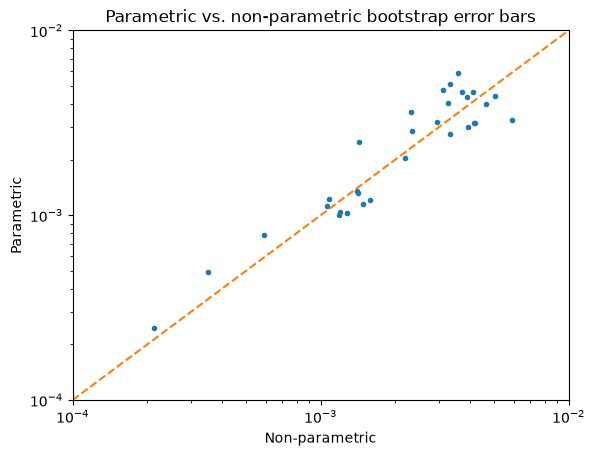

In [20]:
plt.loglog(npboot_std.to_vector(), pboot_std.to_vector(), '.')
plt.loglog(np.logspace(-4, -2, 10), np.logspace(-4, -2, 10), '--')
plt.xlabel('Non-parametric')
plt.ylabel('Parametric')
plt.xlim((1e-4, 1e-2)); plt.ylim((1e-4, 1e-2))
plt.title('Parametric vs. non-parametric bootstrap error bars')
plt.show()